# 08 — MBS Pricer: OAS, Effective Duration & Convexity

Integrates all upstream modules into a Monte Carlo OAS engine:
```text
Vasicek short-rate paths under the RISK-NEUTRAL measure (θ_Q via market price of risk)
  → 30Y mortgage-rate paths (closed-form bond pricing + MBS spread)
  → Rate-dependent CPR paths (CPR-calibrated logistic S-curve)
  → Pool cash flows: net pass-through coupon + scheduled principal
        + voluntary prepayment (SMM) + involuntary default buyout-at-par (Cox MDR)
  → Stochastic discount factors
  → Model price (expected PV across paths)
  → OAS / Z-spread / option cost (Brent's method)
  → Effective Duration & Convexity (±25bp, common random numbers)
  → Rate-shock stress (−200 … +200bp)
```

Representative agency pass-through:
- Original UPB \$1,000,000 · WAC 6.50% · **net pass-through 6.00%** (50bp servicing + g-fee strip) · 30-year FRM
- Discounting under θ_Q (market price of risk pins the model 10Y zero to an assumed current 10Y UST)
- Default modelled as a guarantor **buyout at par** (no loss to the investor)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
sys.path.insert(0, str(Path('..') / 'src'))
import vasicek as v
import prepayment as pp
import cashflow as cf
import pricing as pr

FRED_DIR  = Path('..') / 'data' / 'fred'
PROCESSED = Path('..') / 'data' / 'processed'
FIGURES   = Path('..') / 'artifacts' / 'figures'
RESULTS   = Path('..') / 'artifacts' / 'results'
FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

# ── Pool parameters (representative agency pass-through) ──────────────────────
COUPON       = 0.065        # 6.50% WAC (borrower note rate: amortisation + refi reference)
SERVICE_GFEE = 0.005        # servicing (25bp) + guarantee fee (25bp) strip
NET_COUPON   = COUPON - SERVICE_GFEE   # 6.00% investor pass-through coupon
ORIG_UPB     = 1_000_000.0
TERM         = 360
N_PATHS      = 5_000
SEED         = 42

# ── Pricing-curve assumptions ─────────────────────────────────────────────────
TARGET_10Y   = 0.043        # assumed current 10Y UST → sets risk-neutral θ_Q (only GS1 is in-dataset)
MBS_SPREAD   = 0.015        # primary/secondary mortgage spread over the Vasicek curve

## 1. Load Vasicek parameters

In [2]:
# Physical-measure calibration on GS1
kappa, theta_p, sigma, initial_rate = v.load_and_calibrate(
    start='2000-01-01', end='2025-12-31', cache_path=FRED_DIR / 'gs1_monthly.csv',
)

# Risk-neutral θ_Q via a market price of risk, pinned so the model 10Y zero = TARGET_10Y.
# The physical curve is far too low at the long end (σ²/2κ² convexity drag), which would
# over-discount and inflate price. Pricing uses θ_Q; forecasting (nb 06–07) uses θ_P.
theta_q = v.calibrate_risk_neutral_theta(initial_rate, kappa, sigma, TARGET_10Y, maturity=10.0)
mpr     = v.implied_market_price_of_risk(theta_p, theta_q, kappa, sigma)

print(f'Physical : κ={kappa:.4f}  θ_P={theta_p*100:.2f}%  σ={sigma*100:.3f}%  r₀={initial_rate*100:.2f}%')
print(f'Risk-neutral : θ_Q={theta_q*100:.2f}%  (market price of risk λ={mpr:.4f})')
print(f'Model zero curve (Q): 10Y={v.vasicek_yield(initial_rate,kappa,theta_q,sigma,10)*100:.2f}%  '
      f'30Y={v.vasicek_yield(initial_rate,kappa,theta_q,sigma,30)*100:.2f}%')

# Prepayment S-curve: floor calibrated to the observed pool CPR; in-the-money response
# from PSA convention (sample has no in-the-money episodes to fit).
pool_cpr  = pd.read_parquet(PROCESSED / 'pool_cpr_monthly.parquet')
obs_floor = float(pool_cpr.loc[pool_cpr['cpr'] > 0, 'cpr'].mean())
scurve    = pp.calibrate_scurve_from_pool_cpr(obs_floor)
print(f'\nPrepay S-curve (obs floor CPR={obs_floor*100:.2f}%): {scurve}')

# Default (MDR) buyout-at-par schedule from the Cox baseline hazard (notebook 04)
mdr = pd.read_csv(PROCESSED / 'mdr_schedule.csv')['mdr'].values
print(f'MDR schedule: {mdr.shape[0]} months, lifetime cum default ≈ {(1-np.prod(1-mdr))*100:.1f}%')

κ (mean-reversion speed):  0.0902  [yr⁻¹]
θ (long-run mean):         4.85%
σ (volatility):            1.354%  [yr⁻¹/²]
r₀ (current short rate):   3.79%
Rate half-life:            7.7 years
Physical : κ=0.0902  θ_P=4.85%  σ=1.354%  r₀=3.79%
Risk-neutral : θ_Q=5.76%  (market price of risk λ=-0.0611)
Model zero curve (Q): 10Y=4.30%  30Y=4.53%

Prepay S-curve (obs floor CPR=1.27%): {'k_min': 0.2118360712374331, 'k_max': 6.0, 'alpha': -1.8474870917693174, 'beta': 200.0}
MDR schedule: 360 months, lifetime cum default ≈ 12.4%


## 2. Generate rate and CPR paths

In [3]:
# Short rate paths under the RISK-NEUTRAL measure (θ_Q) for pricing
rate_paths = v.simulate_vasicek(
    initial_rate=initial_rate,
    kappa=kappa, theta=theta_q, sigma=sigma,
    n_paths=N_PATHS, n_steps=TERM,
    time_step=1/12, seed=SEED,
)

# 30Y mortgage rate paths (Vasicek Q yield + MBS spread)
mortgage_paths = v.mortgage_rate_from_short(
    rate_paths, kappa, theta_q, sigma, tau=30.0, mbs_spread=MBS_SPREAD
)

# Rate-dependent CPR → SMM using the CPR-calibrated S-curve (columns 0..359 ≡ months 1..360)
cpr_paths = pp.compute_cpr_paths(mortgage_paths[:, :-1], coupon=COUPON, **scurve)
smm_paths = pp.cpr_to_smm(cpr_paths)

print(f'Rate paths:    {rate_paths.shape}')
print(f'Mortgage paths:{mortgage_paths.shape}  mean={mortgage_paths.mean()*100:.2f}%  '
      f'(refi incentive vs {COUPON*100:.1f}% WAC ≈ {(COUPON-mortgage_paths.mean())*100:+.2f}%)')
print(f'CPR paths:     {cpr_paths.shape}  mean CPR={cpr_paths.mean()*100:.2f}%  yr1={cpr_paths[:,:12].mean()*100:.2f}%')
print(f'SMM paths:     {smm_paths.shape}  mean SMM={smm_paths.mean()*100:.3f}%')

Rate paths:    (5000, 361)
Mortgage paths:(5000, 361)  mean=6.47%  (refi incentive vs 6.5% WAC ≈ +0.03%)
CPR paths:     (5000, 360)  mean CPR=9.42%  yr1=2.48%
SMM paths:     (5000, 360)  mean SMM=0.860%


## 3. Generate cash flows and discount factors

In [4]:
# Investor cash flows: net pass-through coupon + scheduled principal + voluntary prepay
# + involuntary default buyout at par (agency convention — a default is a guarantor buyout).
cashflows, balances = cf.generate_cashflows(
    smm_paths, COUPON, ORIG_UPB, TERM, net_coupon=NET_COUPON, mdr=mdr,
)
disc = cf.compute_discount_factors(rate_paths, time_step=1/12)

print(f'Cash flows: {cashflows.shape}  mean total CF=${cashflows.sum(axis=1).mean():,.0f}')
print(f'Balances:   {balances.shape}   terminal balance=${balances[:,-1].mean():,.2f} (expect ~0)')
print(f'Disc factors: {disc.shape}  t=0 mean={disc[:,0].mean():.5f}  t=359 mean={disc[:,-1].mean():.5f}')

assert (cashflows >= 0).all(), 'Negative cash flows detected'
assert (balances >= 0).all(), 'Negative balances detected'
print('\nSanity checks passed ✓')

Cash flows: (5000, 360)  mean total CF=$1,530,492
Balances:   (5000, 361)   terminal balance=$0.00 (expect ~0)
Disc factors: (5000, 360)  t=0 mean=0.99685  t=359 mean=0.25415

Sanity checks passed ✓


## 4. Model price (OAS = 0)

In [5]:
model_price = pr.price_at_oas(0.0, cashflows, disc)
price_pct   = model_price / ORIG_UPB * 100
pv_paths    = np.sum(cashflows * disc, axis=1)

print(f'MBS Model Price:        ${model_price:>12,.2f}')
print(f'Price as % of par:       {price_pct:.4f}')
print(f'Std dev across paths:    {pv_paths.std()/ORIG_UPB*100:.4f}%')
print(f'P5–P95 price range:      {np.percentile(pv_paths,5)/ORIG_UPB*100:.2f}–{np.percentile(pv_paths,95)/ORIG_UPB*100:.2f}')

MBS Model Price:        $1,077,449.02
Price as % of par:       107.7449
Std dev across paths:    8.1562%
P5–P95 price range:      91.49–117.18


## 5. OAS at different market prices (spec §9.1)

OAS = constant spread λ s.t. E[Σ CF(t,ω) · B(0,t,ω) · exp(-λt·Δt)] = market price.

In [6]:
# OAS = spread over the simulated (vol-on) Treasury paths. Z-spread = same spread over the
# DETERMINISTIC forward curve (σ=0, no optionality). Option cost = Z-spread − OAS captures
# the value of the prepayment option the investor is short.
cf_det, disc_det, *_ = pr.simulate_pool_cashflows(
    initial_rate=initial_rate, kappa=kappa, theta=theta_q, sigma=0.0,
    coupon=COUPON, orig_upb=ORIG_UPB, term=TERM, n_paths=1, seed=SEED,
    net_coupon=NET_COUPON, mdr=mdr, mbs_spread=MBS_SPREAD, prepay_params=scurve,
)

market_prices_pct = [96, 97, 98, 99, 100, 101, 102]
oas_results = []
for price_pct_mkt in market_prices_pct:
    mkt_price = ORIG_UPB * price_pct_mkt / 100
    oas = pr.solve_oas(mkt_price, cashflows, disc)
    zsp = pr.solve_oas(mkt_price, cf_det, disc_det)
    oas_results.append({
        'market_price_pct': price_pct_mkt,
        'oas_bps':          oas * 10_000,
        'z_spread_bps':     zsp * 10_000,
        'option_cost_bps':  (zsp - oas) * 10_000,
    })

oas_df = pd.DataFrame(oas_results)
print(oas_df.to_string(index=False, float_format='%.1f'))
print('\nZ-spread ≈ the assumed 150bp MBS spread (internal check); option cost rises with dollar')
print('price — the signature of premium-MBS negative convexity.')

 market_price_pct  oas_bps  z_spread_bps  option_cost_bps
               96    198.9         194.6             -4.4
               97    180.4         181.1              0.8
               98    162.1         167.9              5.8
               99    144.2         154.9             10.8
              100    126.6         142.2             15.6
              101    109.3         129.7             20.4
              102     92.3         117.3             25.1

Z-spread ≈ the assumed 150bp MBS spread (internal check); option cost rises with dollar
price — the signature of premium-MBS negative convexity.


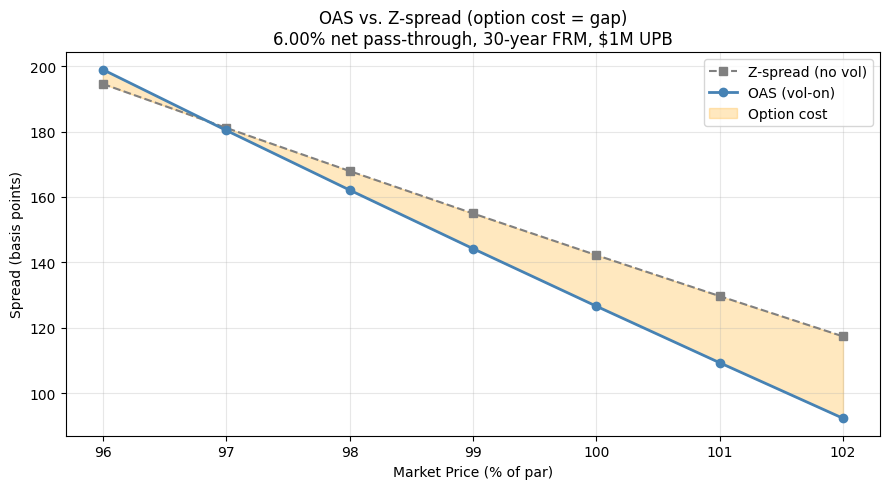

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(oas_df['market_price_pct'], oas_df['z_spread_bps'], 's--', color='gray',
        linewidth=1.5, label='Z-spread (no vol)')
ax.plot(oas_df['market_price_pct'], oas_df['oas_bps'], 'o-', color='steelblue',
        linewidth=2, label='OAS (vol-on)')
ax.fill_between(oas_df['market_price_pct'], oas_df['oas_bps'], oas_df['z_spread_bps'],
                color='orange', alpha=0.25, label='Option cost')
ax.set_title('OAS vs. Z-spread (option cost = gap)\n6.00% net pass-through, 30-year FRM, $1M UPB')
ax.set_xlabel('Market Price (% of par)')
ax.set_ylabel('Spread (basis points)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'mbs_oas_vs_price.png', bbox_inches='tight')
plt.show()

## 6. Effective Duration and Convexity (spec §9.2)

Symmetric finite differences — bump r₀ by ±25bp, reprice, and compute:
```text
EffDur  = (P_dn - P_up) / (2 · P₀ · dr)
EffConv = (P_up + P_dn - 2·P₀) / (P₀ · dr²)
```
Base and both bumps share the **same RNG seed and path count (common random numbers)**, so the convexity term — a difference of nearly-equal large numbers — is signal, not Monte Carlo noise. MBS convexity is negative: prepayment shortens duration as rates fall.

In [8]:
print('Computing effective duration & convexity (common random numbers, 3 × 5,000-path repricing)...')
# Base and both ±25bp bumps are repriced with the SAME seed and path count, so the
# finite differences are clean — essential for the second-order convexity term.
risk_metrics = pr.effective_duration_convexity(
    initial_rate=initial_rate,
    kappa=kappa, theta=theta_q, sigma=sigma,
    coupon=COUPON, orig_upb=ORIG_UPB, term=TERM,
    rate_bump=0.0025, n_paths=N_PATHS, seed=SEED,
    net_coupon=NET_COUPON, mdr=mdr, mbs_spread=MBS_SPREAD, prepay_params=scurve,
)
base_price = risk_metrics['base_price']

print(f'\nBase price:           ${base_price:>12,.2f}  ({base_price/ORIG_UPB*100:.4f}% of par)')
print(f'Price +25bp:          ${risk_metrics["price_up"]:>12,.2f}  ({risk_metrics["price_up"]/ORIG_UPB*100:.4f}%)')
print(f'Price -25bp:          ${risk_metrics["price_dn"]:>12,.2f}  ({risk_metrics["price_dn"]/ORIG_UPB*100:.4f}%)')
print(f'\nEffective Duration:  {risk_metrics["eff_duration"]:.3f} years')
print(f'Effective Convexity: {risk_metrics["eff_convexity"]:.3f}  (negative — prepayment shortens duration as rates fall)')

Computing effective duration & convexity (common random numbers, 3 × 5,000-path repricing)...



Base price:           $1,077,449.02  (107.7449% of par)
Price +25bp:          $1,068,337.48  (106.8337%)
Price -25bp:          $1,086,355.91  (108.6356%)

Effective Duration:  3.345 years
Effective Convexity: -30.388  (negative — prepayment shortens duration as rates fall)


## 7. Price distribution across paths

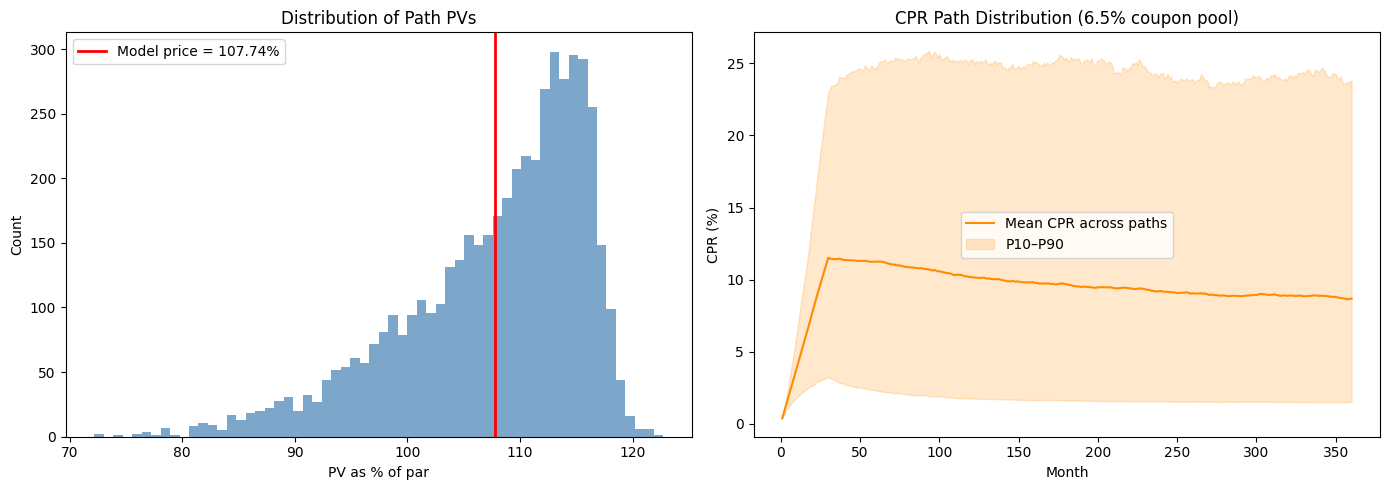

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution of path PVs
axes[0].hist(pv_paths / ORIG_UPB * 100, bins=60, color='steelblue', alpha=0.7)
axes[0].axvline(model_price / ORIG_UPB * 100, color='red', linewidth=2,
                label=f'Model price = {model_price/ORIG_UPB*100:.2f}%')
axes[0].set_title('Distribution of Path PVs')
axes[0].set_xlabel('PV as % of par')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: mean CPR path over time
months = np.arange(1, TERM + 1)
axes[1].plot(months, cpr_paths.mean(axis=0) * 100, color='darkorange', linewidth=1.5,
             label='Mean CPR across paths')
axes[1].fill_between(
    months,
    np.percentile(cpr_paths, 10, axis=0) * 100,
    np.percentile(cpr_paths, 90, axis=0) * 100,
    alpha=0.2, color='darkorange', label='P10–P90'
)
axes[1].set_title('CPR Path Distribution (6.5% coupon pool)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('CPR (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'mbs_price_dist_and_cpr.png', bbox_inches='tight')
plt.show()

## 8. Save results to JSON (spec §10 Phase 8)

## 9. Stress testing — price vs. rate shock (spec §9.3)

Reprice the pool at rate shocks from -200bp to +200bp.  
Negative convexity shows up as: price rises less than linear (duration) predicts at -200bp,  
and falls more than linear predicts at +200bp.

In [10]:
print('Running stress test (7 repricing runs × 5,000 paths each, common random numbers)...')
shocks = [-0.02, -0.01, -0.005, 0.0, 0.005, 0.01, 0.02]
stress_rows = []

for shock in shocks:
    stressed_price = pr.mbs_price_at_rate(
        rate_shift=shock, initial_rate=initial_rate,
        kappa=kappa, theta=theta_q, sigma=sigma,
        coupon=COUPON, orig_upb=ORIG_UPB, term=TERM,
        n_paths=N_PATHS, seed=SEED,
        net_coupon=NET_COUPON, mdr=mdr, mbs_spread=MBS_SPREAD, prepay_params=scurve,
    )
    duration_only = -risk_metrics['eff_duration'] * shock          # linear (duration-only) prediction
    stress_rows.append({
        'rate_shock_bps':        int(shock * 10_000),
        'price_pct':             stressed_price / ORIG_UPB * 100,
        'price_chg_pct':         (stressed_price / base_price - 1) * 100,
        'duration_only_chg_pct': duration_only * 100,
    })

stress_df = pd.DataFrame(stress_rows)
print(stress_df.to_string(index=False, float_format='%.4f'))
print('\nNegative convexity: at -200bp the MC gain (+) is LESS than the duration-only line,')
print('while at +200bp the MC loss (-) is MORE than the line.')

Running stress test (7 repricing runs × 5,000 paths each, common random numbers)...


 rate_shock_bps  price_pct  price_chg_pct  duration_only_chg_pct
           -200   114.3002         6.0841                 6.6893
           -100   111.1822         3.1902                 3.3446
            -50   109.5054         1.6339                 1.6723
              0   107.7449         0.0000                -0.0000
             50   105.9028        -1.7097                -1.6723
            100   103.9857        -3.4890                -3.3446
            200    99.9690        -7.2169                -6.6893

Negative convexity: at -200bp the MC gain (+) is LESS than the duration-only line,
while at +200bp the MC loss (-) is MORE than the line.


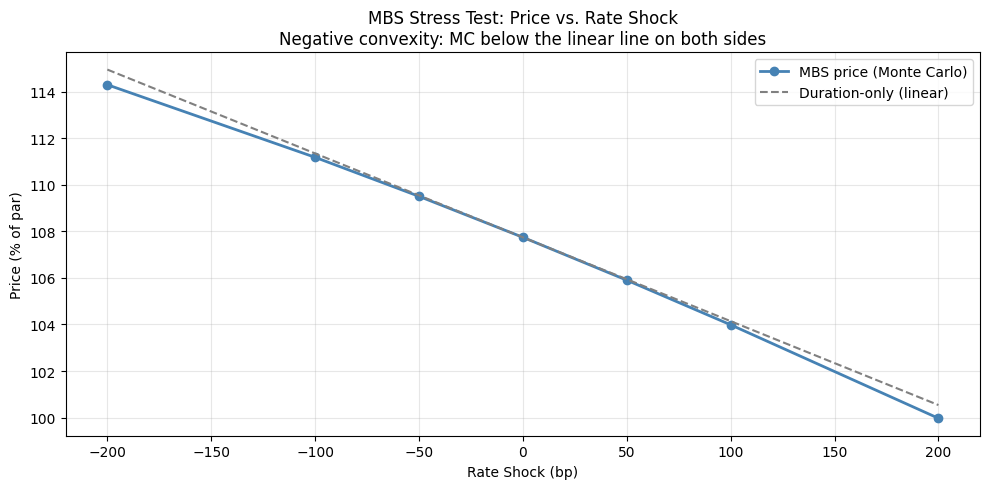

In [11]:
base_pct = base_price / ORIG_UPB * 100
duration_line = base_pct * (1 + stress_df['duration_only_chg_pct'] / 100)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(stress_df['rate_shock_bps'], stress_df['price_pct'], 'o-',
        color='steelblue', linewidth=2, label='MBS price (Monte Carlo)')
ax.plot(stress_df['rate_shock_bps'], duration_line, '--',
        color='gray', linewidth=1.5, label='Duration-only (linear)')
ax.set_title('MBS Stress Test: Price vs. Rate Shock\n'
             'Negative convexity: MC below the linear line on both sides')
ax.set_xlabel('Rate Shock (bp)')
ax.set_ylabel('Price (% of par)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'mbs_stress_test.png', bbox_inches='tight')
plt.show()

In [12]:
import json

results = {
    "pool": {"wac": COUPON, "net_coupon": NET_COUPON, "servicing_gfee_strip": SERVICE_GFEE,
             "orig_upb": ORIG_UPB, "term": TERM},
    "vasicek": {
        "kappa": round(kappa, 6), "theta_physical": round(theta_p, 6),
        "theta_risk_neutral": round(theta_q, 6), "sigma": round(sigma, 8),
        "initial_rate": round(initial_rate, 6), "market_price_of_risk": round(mpr, 5),
        "model_10y_zero": round(float(v.vasicek_yield(initial_rate, kappa, theta_q, sigma, 10)), 5),
        "model_30y_zero": round(float(v.vasicek_yield(initial_rate, kappa, theta_q, sigma, 30)), 5),
        "target_10y_assumed": TARGET_10Y,
    },
    "prepayment": {"observed_cpr_floor": round(obs_floor, 5),
                   **{k: round(val, 4) for k, val in scurve.items()},
                   "mean_cpr_life": round(float(cpr_paths.mean()), 4),
                   "mean_cpr_yr1": round(float(cpr_paths[:, :12].mean()), 4)},
    "pricing": {"n_paths": N_PATHS, "model_price": round(model_price, 2),
                "model_price_pct": round(model_price / ORIG_UPB * 100, 4),
                "price_std_pct": round(float(pv_paths.std()) / ORIG_UPB * 100, 4)},
    "risk_metrics": {
        "rate_bump_bps": 25, "n_paths": N_PATHS,
        "base_price_pct": round(base_price / ORIG_UPB * 100, 4),
        "price_up_pct": round(risk_metrics["price_up"] / ORIG_UPB * 100, 4),
        "price_dn_pct": round(risk_metrics["price_dn"] / ORIG_UPB * 100, 4),
        "eff_duration": round(risk_metrics["eff_duration"], 4),
        "eff_convexity": round(risk_metrics["eff_convexity"], 4),
        "common_random_numbers": True,
    },
    "oas_table": [{"market_price_pct": r["market_price_pct"],
                   "oas_bps": round(r["oas_bps"], 1),
                   "z_spread_bps": round(r["z_spread_bps"], 1),
                   "option_cost_bps": round(r["option_cost_bps"], 1)} for r in oas_results],
    "stress_table": [{"rate_shock_bps": r["rate_shock_bps"],
                      "price_pct": round(r["price_pct"], 4),
                      "price_chg_pct": round(r["price_chg_pct"], 4),
                      "duration_only_chg_pct": round(r["duration_only_chg_pct"], 4)} for r in stress_rows],
}

out_path = RESULTS / 'mbs_pricing_results.json'
with open(out_path, 'w', encoding='utf-8') as fh:
    json.dump(results, fh, indent=2)
print(f'Results saved to: {out_path}')
print(json.dumps(results, indent=2))

Results saved to: ../artifacts/results/mbs_pricing_results.json
{
  "pool": {
    "wac": 0.065,
    "net_coupon": 0.060000000000000005,
    "servicing_gfee_strip": 0.005,
    "orig_upb": 1000000.0,
    "term": 360
  },
  "vasicek": {
    "kappa": 0.090249,
    "theta_physical": 0.048481,
    "theta_risk_neutral": 0.057643,
    "sigma": 0.01354326,
    "initial_rate": 0.0379,
    "market_price_of_risk": -0.06106,
    "model_10y_zero": 0.043,
    "model_30y_zero": 0.04527,
    "target_10y_assumed": 0.043
  },
  "prepayment": {
    "observed_cpr_floor": 0.01271,
    "k_min": 0.2118,
    "k_max": 6.0,
    "alpha": -1.8475,
    "beta": 200.0,
    "mean_cpr_life": 0.0942,
    "mean_cpr_yr1": 0.0248
  },
  "pricing": {
    "n_paths": 5000,
    "model_price": 1077449.02,
    "model_price_pct": 107.7449,
    "price_std_pct": 8.1562
  },
  "risk_metrics": {
    "rate_bump_bps": 25,
    "n_paths": 5000,
    "base_price_pct": 107.7449,
    "price_up_pct": 106.8337,
    "price_dn_pct": 108.6356,
  